
<div style="background: linear-gradient(90deg, #1B3A4B 0%, #2C5F6D 100%); padding: 28px 32px; border-radius: 10px; color: #F4EDE4;">
<h1 style="margin:0; color:#F4EDE4;">Domestic Violence Incidents (Medium Risk) — KPI Time Series Analysis</h1>
<p style="margin-top:8px; color:#CFE3E0; font-size:15px;">KPI <code>DOMV9a</code>, 2011–2019 · Reproducible notebook, built on the <code>src/</code> package</p>
</div>

## Executive Summary

This notebook is a full statistical audit of a single administrative KPI: **`DOMV9a` — Domestic Violence Incidents Level (Medium Risk)**, reported monthly/quarterly/annually by a UK local authority, FY2011/12–2018/19.

Unlike a typical exploratory notebook, **every number and chart here is produced by calling the project's `src/` package** (`src.data_loader`, `src.validation`, `src.analysis`, `src.forecasting`, `src.theme`) — the same tested code used by `src/pipeline.py` and `app/streamlit_app.py`. This notebook cannot silently diverge from the pipeline's numbers.

**Headline findings** (each derived and validated later in this notebook):

| # | Finding | Section |
|---|---|---|
| 1 | The raw file mixes three time granularities for one KPI — disaggregated via `src.data_loader.classify_granularity`. | §5–7 |
| 2 | Monthly sums match reported annual totals **exactly** for all 4 complete years — validated via `src.validation.reconcile_monthly_vs_annual`. | §9 |
| 3 | Incidents rose 278→463→621→715 (2011/12→2014/15), but growth **decelerated** every year (+66.5%→+34.1%→+15.1%). | §11–12 |
| 4 | No statistically significant seasonality (ANOVA p≈0.85) despite a visually suggestive winter bump. | §13 |
| 5 | Two distinct gap regimes: a declared "Not Collected" interruption (Aug 2015–Mar 2017) and an apparently incomplete later extract (FY17/18 absent; FY18/19 blank). | §8 |
| 6 | A trend+seasonal model, validated out-of-sample on 4 held-out months, beats a naive baseline (MAE 7.7 vs 8.75). | §16 |

**Interpretation caveat:** this is a *recorded-incidents* KPI, not a prevalence measure. See §17–18.



## 1. Introduction & Analytical Objectives

### 1.1 Why this KPI matters
Medium-risk domestic violence (DV) incident counts feed directly into how a local Community Safety Partnership allocates MARAC capacity, IDVA staffing, and refuge commissioning.

### 1.2 Objective
Given a small (107-row), multi-granularity, partially-missing administrative time series, what can we responsibly claim about the level and trend of medium-risk DV incidents — and what can we **not** claim?

### 1.3 Guiding principles
- **Validate before trusting** (§9). **Separate observation from inference** (§11 vs §12). **Quantify uncertainty** (every trend/seasonal claim carries a test + p-value). **Treat missingness as data** (§8). **Prefer honest small numbers over false precision** (§16 avoids over-fitting a ~48-point series).



## 2. Data Provenance, KPI Definition & Ethical Framing

| Field | Meaning |
|---|---|
| `kpiId` | Stable KPI code — constant: `DOMV9a` |
| `KpiName` | *"Domestic Violence Incidents Level – Medium Risk"* |
| `value` | Free-text count, e.g. `"15.00 Number"`, or `"NC"` (Not Collected), or blank |
| `period` | Composite key: financial year + granularity, e.g. `2013/2014_Q2`, `2013/2014_Nov`, `2013/2014` |
| `StartDate`/`EndDate` | Exact calendar window |

**Ethical framing.** This is aggregate, de-identified administrative statistics — no individual is identifiable. Trends are described as *recorded incidents*, never as direct proxies for lived harm.



## 3. Environment Setup

We import the project's own `src/` package rather than redefining logic. The color theme (§ config.yaml `theme:`) is loaded once via `src.theme.configure()` and applied to every chart in this notebook through `src.theme.apply_theme()`.


In [1]:

import sys
from pathlib import Path

# Make the project root importable (this notebook lives in notebooks/).
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import data_loader, validation, analysis, forecasting, theme
from src.config import load_config

config = load_config(PROJECT_ROOT / "config.yaml")
th = theme.configure(config)

pd.set_option("display.max_rows", 30)
print(f"Project: {config.project_name}  |  KPI: {config.kpi_id}")
print("Theme:", list(th.keys()))


Project: domestic-violence-kpi-analysis  |  KPI: DOMV9a
Theme: ['ink', 'teal', 'rose', 'amber', 'grey', 'paper', 'grid', 'text']



## 4. Data Ingestion & Schema Inspection


In [2]:

raw = data_loader.load_raw(config)
print(f"Shape: {raw.shape[0]} rows x {raw.shape[1]} columns\n")
raw.head(8)


Shape: 107 rows x 8 columns



,kpiId,KpiName,value,DataType,period,StartDate,EndDate,CollectionFrequency
0,DOMV9a,Domestic Violence Incidents Level - Medium Risk,15.00 Number,Number,2011/2012_Apr,01/04/2011,30/04/2011,Monthly
1,DOMV9a,Domestic Violence Incidents Level - Medium Risk,36.00 Number,Number,2011/2012_Q1,01/04/2011,30/06/2011,Monthly
2,DOMV9a,Domestic Violence Incidents Level - Medium Risk,278.00 Number,Number,2011/2012,01/04/2011,31/03/2012,Monthly
3,DOMV9a,Domestic Violence Incidents Level - Medium Risk,9.00 Number,Number,2011/2012_May,01/05/2011,31/05/2011,Monthly
4,DOMV9a,Domestic Violence Incidents Level - Medium Risk,12.00 Number,Number,2011/2012_Jun,01/06/2011,30/06/2011,Monthly
5,DOMV9a,Domestic Violence Incidents Level - Medium Risk,50.00 Number,Number,2011/2012_Q2,01/07/2011,30/09/2011,Monthly
6,DOMV9a,Domestic Violence Incidents Level - Medium Risk,16.00 Number,Number,2011/2012_Jul,01/07/2011,31/07/2011,Monthly
7,DOMV9a,Domestic Violence Incidents Level - Medium Risk,13.00 Number,Number,2011/2012_Aug,01/08/2011,31/08/2011,Monthly


In [3]:

for col in ["kpiId", "KpiName", "DataType", "CollectionFrequency"]:
    print(f"{col:22s} -> {raw[col].nunique()} unique value(s): {raw[col].unique().tolist()}")


kpiId                  -> 1 unique value(s): ['DOMV9a']
KpiName                -> 1 unique value(s): ['Domestic Violence Incidents Level - Medium Risk']
DataType               -> 1 unique value(s): ['Number']
CollectionFrequency    -> 1 unique value(s): ['Monthly']



## 5. Data Cleaning & Type Harmonization

`src.data_loader.clean()` handles three problems in one auditable pass: numeric-magnitude extraction, an explicit `"Not Collected"` flag (kept distinct from a blank), and decomposing `period` into `financial_year` + `granularity`.


In [4]:

df = data_loader.clean(raw)
df[["period", "financial_year", "granularity", "value", "value_num", "not_collected", "StartDate"]].head(10)


,period,financial_year,granularity,value,value_num,not_collected,StartDate
0,2011/2012_Apr,2011/2012,Monthly,15.00 Number,15.0,False,2011-04-01
1,2011/2012_Q1,2011/2012,Quarterly,36.00 Number,36.0,False,2011-04-01
2,2011/2012,2011/2012,Annual,278.00 Number,278.0,False,2011-04-01
3,2011/2012_May,2011/2012,Monthly,9.00 Number,9.0,False,2011-05-01
4,2011/2012_Jun,2011/2012,Monthly,12.00 Number,12.0,False,2011-06-01
5,2011/2012_Q2,2011/2012,Quarterly,50.00 Number,50.0,False,2011-07-01
6,2011/2012_Jul,2011/2012,Monthly,16.00 Number,16.0,False,2011-07-01
7,2011/2012_Aug,2011/2012,Monthly,13.00 Number,13.0,False,2011-08-01
8,2011/2012_Sep,2011/2012,Monthly,21.00 Number,21.0,False,2011-09-01
9,2011/2012_Oct,2011/2012,Monthly,18.00 Number,18.0,False,2011-10-01



## 6. Data Quality Audit


In [5]:

quality = validation.data_quality_summary(df)
quality


,n_rows,n_valid_numeric,n_flagged_NC,n_blank_missing
granularity,,,,
Annual,7,4,2,1
Monthly,72,52,8,12
Quarterly,28,17,7,4
TOTAL,107,73,17,17


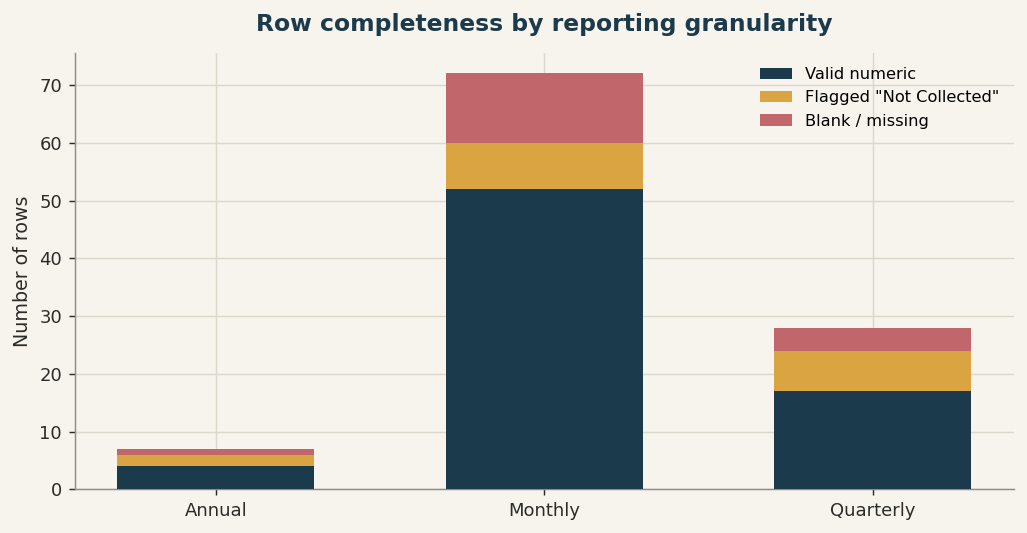

In [6]:

fig, ax = theme.new_fig((8, 4.2))
gran = quality.drop("TOTAL")
x = np.arange(len(gran))
valid, nc, blank = gran["n_valid_numeric"], gran["n_flagged_NC"], gran["n_blank_missing"]
ax.bar(x, valid, 0.6, color=th["ink"], label="Valid numeric", zorder=3)
ax.bar(x, nc, 0.6, bottom=valid, color=th["amber"], label='Flagged "Not Collected"', zorder=3)
ax.bar(x, blank, 0.6, bottom=valid + nc, color=th["rose"], label="Blank / missing", zorder=3)
ax.set_xticks(x); ax.set_xticklabels(gran.index)
theme.apply_theme(ax, th, title="Row completeness by reporting granularity", ylabel="Number of rows")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()



Monthly rows carry the bulk of both valid values and gaps, and quarterly/annual rows track the *same* underlying gaps — confirming missingness is a genuine collection-period problem, not a granularity-encoding artifact.



## 7. Temporal Coverage & Gap Mapping


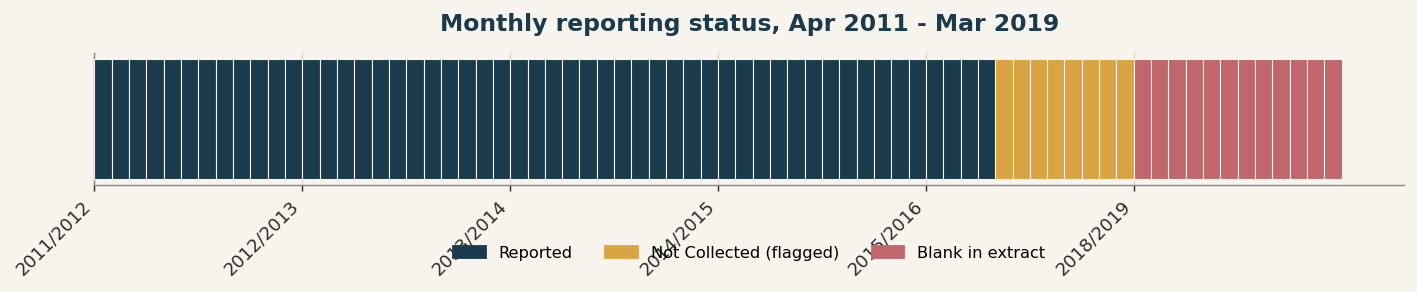

In [7]:

monthly_all = df[df["granularity"] == "Monthly"].sort_values("StartDate").reset_index(drop=True)
monthly_all = data_loader.month_status(monthly_all)

status_color = {"Reported": th["ink"], "Not Collected (flagged)": th["amber"], "Blank in extract": th["rose"]}
fig, ax = theme.new_fig((11, 2.6))
for i, row in monthly_all.iterrows():
    ax.barh(0, 1, left=i, color=status_color[row["status"]], edgecolor=th["paper"], linewidth=0.6, zorder=3)
fy_starts = monthly_all[monthly_all["StartDate"].dt.month == 4].reset_index()
ax.set_xticks(fy_starts["index"]); ax.set_xticklabels(fy_starts["financial_year"], rotation=45, ha="right", fontsize=8)
ax.set_yticks([])
theme.apply_theme(ax, th, title="Monthly reporting status, Apr 2011 - Mar 2019")
handles = [plt.Rectangle((0,0),1,1, color=c) for c in status_color.values()]
ax.legend(handles, status_color.keys(), loc="upper center", bbox_to_anchor=(0.5, -0.35), ncol=3, frameon=False, fontsize=9)
plt.tight_layout(); plt.show()



**Two distinct gap regimes:** (1) Aug 2015–Mar 2017, explicitly flagged `"NC"` — a *declared* collection interruption. (2) Apr 2018–Mar 2019, blank with no flag, and **FY2017/18 entirely absent** — an apparently *incomplete extract*, a different failure mode. This distinction matters directly for §17 (limitations): the forecast in §16 is not extrapolated across either gap.



## 8. Reconstructing a Clean, Analysis-Ready Monthly Series

Only monthly rows with a genuinely reported value are kept for time-series work (`src.data_loader.build_clean_monthly`). Quarterly/annual rows are held back specifically for the §9 reconciliation check.


In [8]:

clean_monthly = data_loader.build_clean_monthly(df)
print(f"Clean monthly observations retained: {len(clean_monthly)} (of {len(monthly_all)} monthly rows in the raw file)")
clean_monthly[["period", "StartDate", "value_num"]].tail(6)


Clean monthly observations retained: 52 (of 72 monthly rows in the raw file)


,period,StartDate,value_num
46,2014/2015_Feb,2015-02-01,54.0
47,2014/2015_Mar,2015-03-01,70.0
48,2015/2016_Apr,2015-04-01,66.0
49,2015/2016_May,2015-05-01,75.0
50,2015/2016_Jun,2015-06-01,54.0
51,2015/2016_Jul,2015-07-01,66.0



## 9. Internal Consistency Validation: Does the Monthly Data Add Up?

The first genuinely *original* check: for every year with complete 12-month coverage, does summing monthly values reproduce the independently-reported annual total?


In [9]:

reconciliation = validation.reconcile_monthly_vs_annual(df, clean_monthly)
reconciliation


,monthly_sum,count,annual_reported,complete_year,discrepancy
financial_year,,,,,
2011/2012,278.0,12,278.0,True,0.0
2012/2013,463.0,12,463.0,True,0.0
2013/2014,621.0,12,621.0,True,0.0
2014/2015,715.0,12,715.0,True,0.0
2015/2016,261.0,4,NaN,False,NaN



**Result:** for the four financial years with complete coverage (2011/12–2014/15), monthly sums match the reported annual figure **exactly — a discrepancy of 0 in every case**. `src.validation.assert_reconciliation_clean()` enforces this as a hard gate in `src/pipeline.py`: the pipeline raises rather than proceeds if this check ever fails on new data.



## 10. Descriptive Statistics & Distributional Analysis


In [10]:

from scipy import stats as _stats
desc = clean_monthly["value_num"].describe().to_frame("Monthly incident count")
desc.loc["skewness"] = _stats.skew(clean_monthly["value_num"])
desc.loc["kurtosis (excess)"] = _stats.kurtosis(clean_monthly["value_num"])
desc


,Monthly incident count
count,52.000000
mean,44.961538
std,18.546139
min,9.000000
25%,32.500000
50%,48.500000
75%,57.500000
max,82.000000
skewness,-0.281851
kurtosis (excess),-0.747147


/tmp/ipykernel_979/1999669264.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_year, labels=years_present, patch_artist=True, zorder=3)


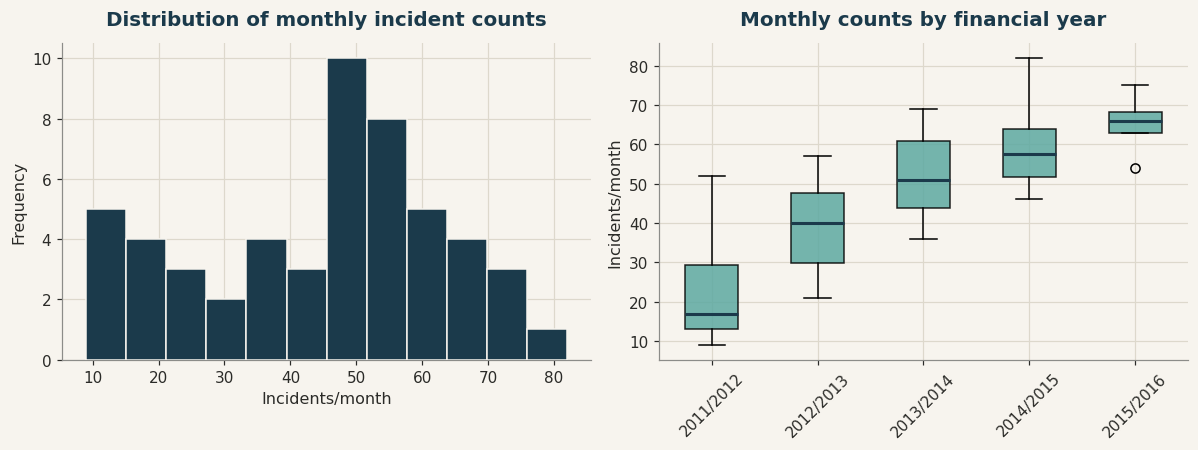

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=110)
axes[0].hist(clean_monthly["value_num"], bins=12, color=th["ink"], edgecolor=th["paper"], zorder=3)
theme.apply_theme(axes[0], th, title="Distribution of monthly incident counts", xlabel="Incidents/month", ylabel="Frequency")

years_present = sorted(clean_monthly["financial_year"].unique())
data_by_year = [clean_monthly.loc[clean_monthly["financial_year"] == fy, "value_num"].values for fy in years_present]
bp = axes[1].boxplot(data_by_year, labels=years_present, patch_artist=True, zorder=3)
for patch in bp["boxes"]:
    patch.set_facecolor(th["teal"]); patch.set_alpha(0.85)
for m in bp["medians"]:
    m.set_color(th["ink"]); m.set_linewidth(2)
theme.apply_theme(axes[1], th, title="Monthly counts by financial year", ylabel="Incidents/month")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()



## 11. Annual Trend Analysis & Growth Dynamics


In [12]:

annual_reported = df[(df["granularity"] == "Annual") & df["value_num"].notna()].set_index("financial_year")["value_num"]
annual_complete = annual_reported.loc[config.complete_financial_years].to_frame("total_incidents")
yoy = analysis.yoy_change(annual_complete["total_incidents"])
yoy


,total_incidents,yoy_change,yoy_pct
financial_year,,,
2011/2012,278.0,NaN,NaN
2012/2013,463.0,185.0,66.546763
2013/2014,621.0,158.0,34.125270
2014/2015,715.0,94.0,15.136876


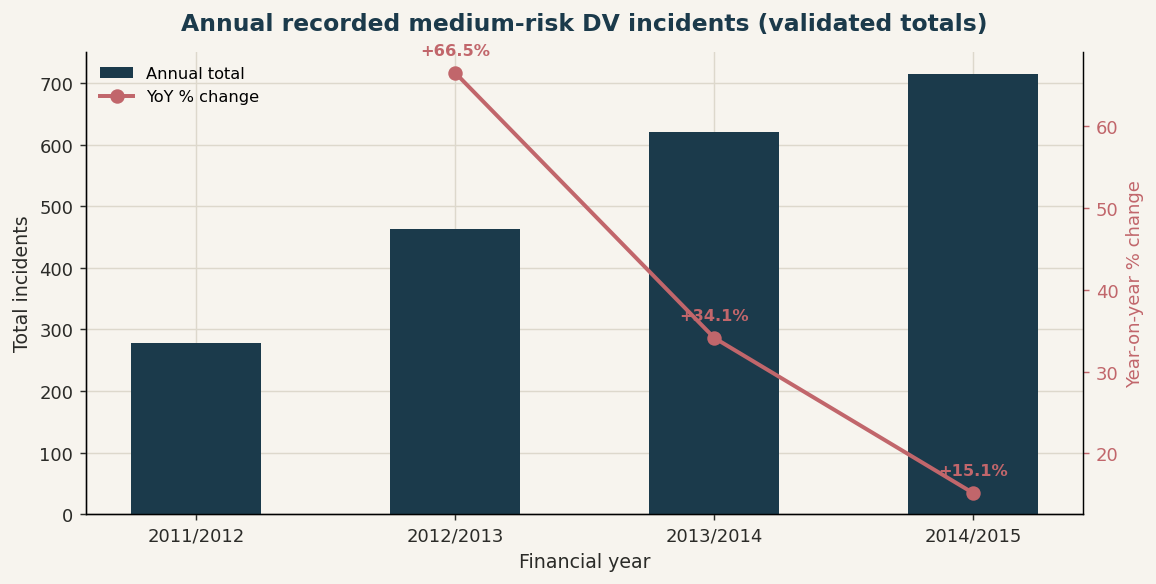

In [13]:

fig, ax1 = theme.new_fig((9, 4.6))
x = np.arange(len(annual_complete))
ax1.bar(x, annual_complete["total_incidents"], color=th["ink"], width=0.5, zorder=3, label="Annual total")
theme.apply_theme(ax1, th, title="Annual recorded medium-risk DV incidents (validated totals)",
                   xlabel="Financial year", ylabel="Total incidents")
ax1.set_xticks(x); ax1.set_xticklabels(annual_complete.index)

ax2 = ax1.twinx()
ax2.plot(x, yoy["yoy_pct"], color=th["rose"], marker="o", linewidth=2.2, markersize=7, zorder=4, label="YoY % change")
ax2.set_ylabel("Year-on-year % change", color=th["rose"])
ax2.tick_params(axis="y", colors=th["rose"]); ax2.spines["top"].set_visible(False); ax2.grid(False)
for i, v in enumerate(yoy["yoy_pct"]):
    if not np.isnan(v):
        ax2.annotate(f"{v:+.1f}%", (i, v), textcoords="offset points", xytext=(0, 10),
                     ha="center", fontsize=9, color=th["rose"], fontweight="bold")
l1, lb1 = ax1.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc="upper left", frameon=False, fontsize=9)
plt.tight_layout(); plt.show()



**Decelerating growth, not accelerating growth.** Levels rose every year (278→463→621→715) but the *rate* fell monotonically: +66.5%→+34.1%→+15.1%. Consistent with an early ramp-up (e.g. a new risk-assessment pathway coming into full use) now saturating, rather than an open-ended escalation.



## 12. Statistical Significance of the Trend

`src.analysis.annual_trend_tests()` reports Kendall's tau and OLS regression side by side, deliberately, so neither is cherry-picked.


In [14]:

trend_tests = analysis.annual_trend_tests(annual_complete["total_incidents"])
trend_tests


,test,statistic,p_value,r_squared
0,Kendall's tau (monotonic trend),1.0,0.083333,NaN
1,OLS linear regression (rate of change),146.9,0.009766,0.980564



**Honest interpretation:** OLS is significant (p≈0.0098, R²=0.98) but with n=4 this is close to a mechanical consequence of near-collinear points. Kendall's tau=1.0 (perfect rank agreement) is directionally consistent, but its own p-value (0.083) is **not** significant at α=0.05 — the smallest possible p-value at n=4 is 0.083, a power limitation, not a sign the trend is weak. **The direction is well supported; the precise linear rate (~147/year) should be read as a rough average, not a reliable extrapolation constant** — which is why §16's forecast is validated out-of-sample rather than trusted on face value.



## 13. Seasonality Analysis: Is There a Month-of-Year Effect?

Using only the four financial years with complete monthly coverage — the sole window where a fair, equally-weighted seasonal comparison is possible.


In [15]:

seasonal_summary, f_stat, p_anova = analysis.seasonality_anova(clean_monthly, config.complete_financial_years)
print(f"One-way ANOVA across calendar months: F = {f_stat:.3f}, p = {p_anova:.3f}")
seasonal_summary


One-way ANOVA across calendar months: F = 0.555, p = 0.851


,mean,std,n
month_name,,,
Apr,33.25,14.840822,4
May,34.75,21.093048,4
Jun,35.00,21.939310,4
Jul,42.75,22.246723,4
Aug,36.75,18.803812,4
Sep,42.00,28.786571,4
Oct,43.25,17.346950,4
Nov,51.50,27.670682,4
Dec,50.00,16.673332,4


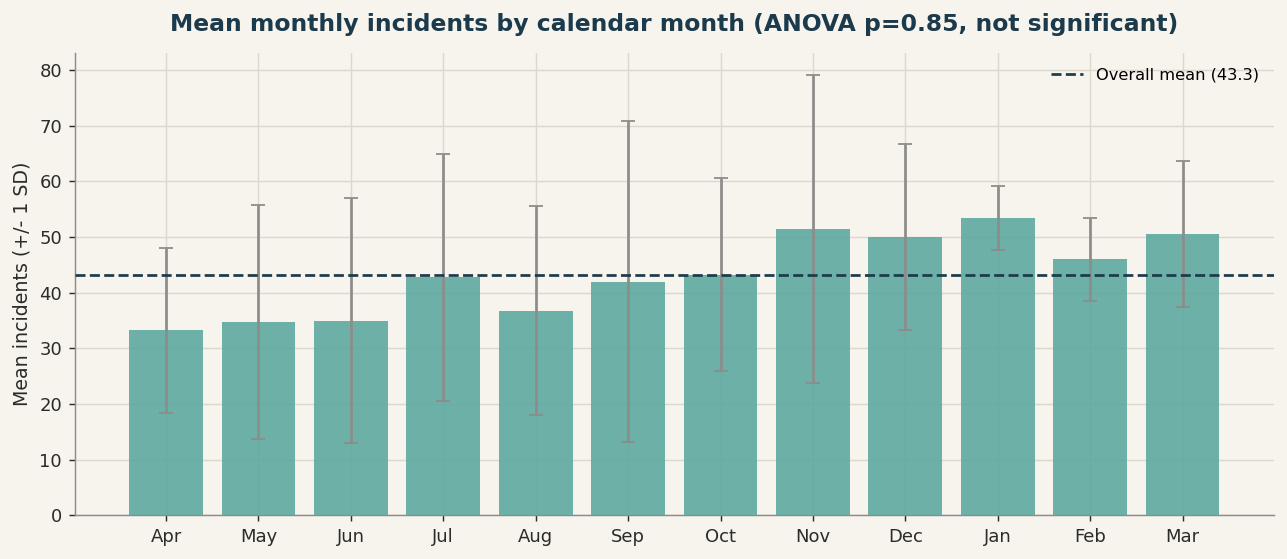

In [16]:

fig, ax = theme.new_fig((10, 4.4))
x = np.arange(len(analysis.MONTH_ORDER))
ax.bar(x, seasonal_summary["mean"], yerr=seasonal_summary["std"], capsize=4, color=th["teal"], ecolor=th["grey"], zorder=3, alpha=0.9)
overall_mean = clean_monthly[clean_monthly["financial_year"].isin(config.complete_financial_years)]["value_num"].mean()
ax.axhline(overall_mean, color=th["ink"], linestyle="--", linewidth=1.5, label=f"Overall mean ({overall_mean:.1f})", zorder=4)
ax.set_xticks(x); ax.set_xticklabels(analysis.MONTH_ORDER)
theme.apply_theme(ax, th, title=f"Mean monthly incidents by calendar month (ANOVA p={p_anova:.2f}, not significant)", ylabel="Mean incidents (+/- 1 SD)")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()



**No statistically significant seasonality** (p≈0.85). The visual winter bump (Nov/Jan/Dec/Mar above spring/summer) is well within what year-to-year noise alone would produce — the correct, rigorous answer is "no effect detected," even though a purely visual read would tempt a false positive.



## 14. Structural Break / Regime Analysis

`src.analysis.structural_break_scan()` fits two independent linear segments at every candidate breakpoint and returns the SSR-minimising split — a simple, fully auditable alternative to an opaque multi-parameter change-point model, appropriate for a 48-point series.


In [17]:

contig = clean_monthly[
    (clean_monthly["StartDate"] >= config.train_start_date) & (clean_monthly["StartDate"] <= config.train_end_date)
].sort_values("StartDate").reset_index(drop=True)
contig["t"] = np.arange(len(contig))

break_result = analysis.structural_break_scan(contig["t"].values, contig["value_num"].values,
                                               min_segment=config.structural_break_min_segment)
for k, v in break_result.items():
    print(f"{k:24s}: {v:.2f}" if isinstance(v, float) else f"{k:24s}: {v}")


single_trend_slope      : 1.07
single_trend_intercept  : 18.22
single_trend_ssr        : 5070.55
best_breakpoint_t       : 33
best_ssr                : 4151.80
ssr_improvement_pct     : 18.12
segment1_slope          : 1.50
segment1_intercept      : 13.00
segment2_slope          : 1.36
segment2_intercept      : 2.43


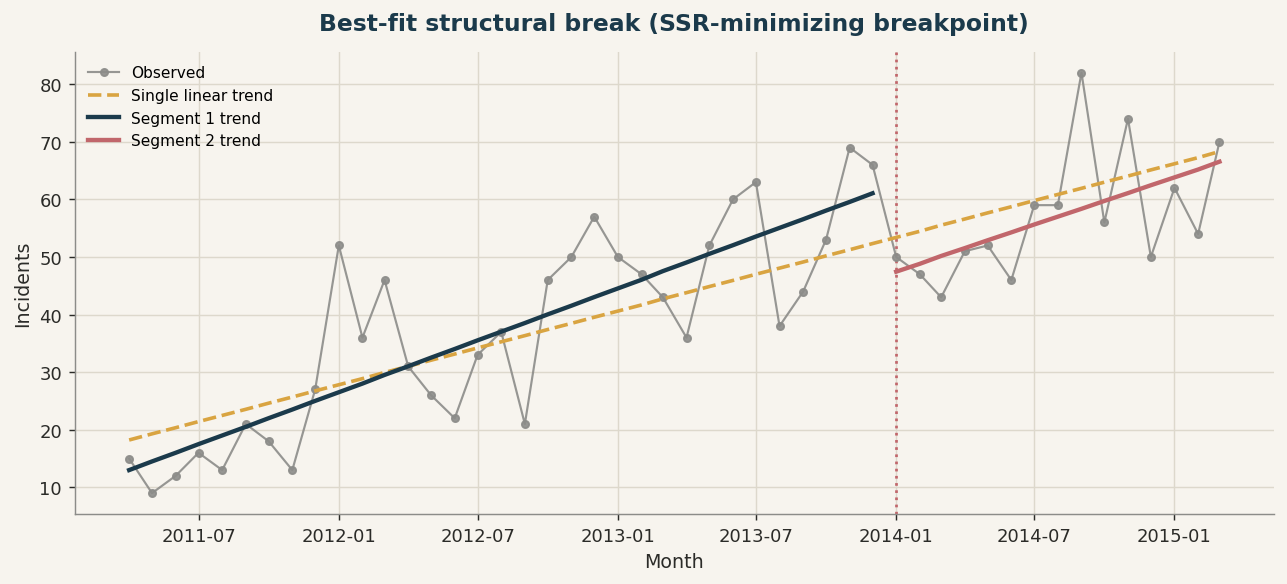

In [18]:

fig, ax = theme.new_fig((10, 4.6))
t, y = contig["t"].values, contig["value_num"].values
ax.plot(contig["StartDate"], y, color=th["grey"], marker="o", markersize=4, linewidth=1.2, alpha=0.9, zorder=3, label="Observed")
ax.plot(contig["StartDate"], break_result["single_trend_intercept"] + break_result["single_trend_slope"]*t,
        color=th["amber"], linewidth=2, linestyle="--", zorder=4, label="Single linear trend")
bp = break_result["best_breakpoint_t"]
left, right = t < bp, t >= bp
ax.plot(contig.loc[left, "StartDate"], break_result["segment1_intercept"] + break_result["segment1_slope"]*t[left],
        color=th["ink"], linewidth=2.4, zorder=5, label="Segment 1 trend")
ax.plot(contig.loc[right, "StartDate"], break_result["segment2_intercept"] + break_result["segment2_slope"]*t[right],
        color=th["rose"], linewidth=2.4, zorder=5, label="Segment 2 trend")
ax.axvline(contig.loc[contig["t"] == bp, "StartDate"].values[0], color=th["rose"], linestyle=":", linewidth=1.5, zorder=2)
theme.apply_theme(ax, th, title="Best-fit structural break (SSR-minimizing breakpoint)", xlabel="Month", ylabel="Incidents")
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
plt.tight_layout(); plt.show()



The best-fit split shows a steeper early ramp and a shallower later climb — consistent with the annual-level deceleration in §11–12, now localised to roughly a specific month. No formal significance test was run for the break itself (e.g. a Chow test), so this is presented as *descriptive*, not confirmatory, evidence (§17).



## 15. Outlier & Anomaly Detection

`src.analysis.detect_outliers()` runs a global Tukey IQR screen and a within-financial-year z-score screen, since the second can catch anomalies the first misses once the whole series has shifted level across years.


In [19]:

outliers = analysis.detect_outliers(clean_monthly, iqr_multiplier=config.iqr_multiplier,
                                     z_threshold=config.within_year_zscore_threshold)
print(f"Global IQR bounds: {outliers['iqr_bounds']}  ->  {len(outliers['global_outliers'])} outlier(s)")
print(f"Within-year |z|>{config.within_year_zscore_threshold} check           ->  {len(outliers['local_outliers'])} outlier(s)")
outliers["local_outliers"][["period", "value_num", "fy_z"]] if len(outliers["local_outliers"]) else "None found"


Global IQR bounds: (-5.0, 95.0)  ->  0 outlier(s)
Within-year |z|>2.0 check           ->  2 outlier(s)


,period,value_num,fy_z
9,2011/2012_Jan,52.0,2.122899
41,2014/2015_Sep,82.0,2.173103


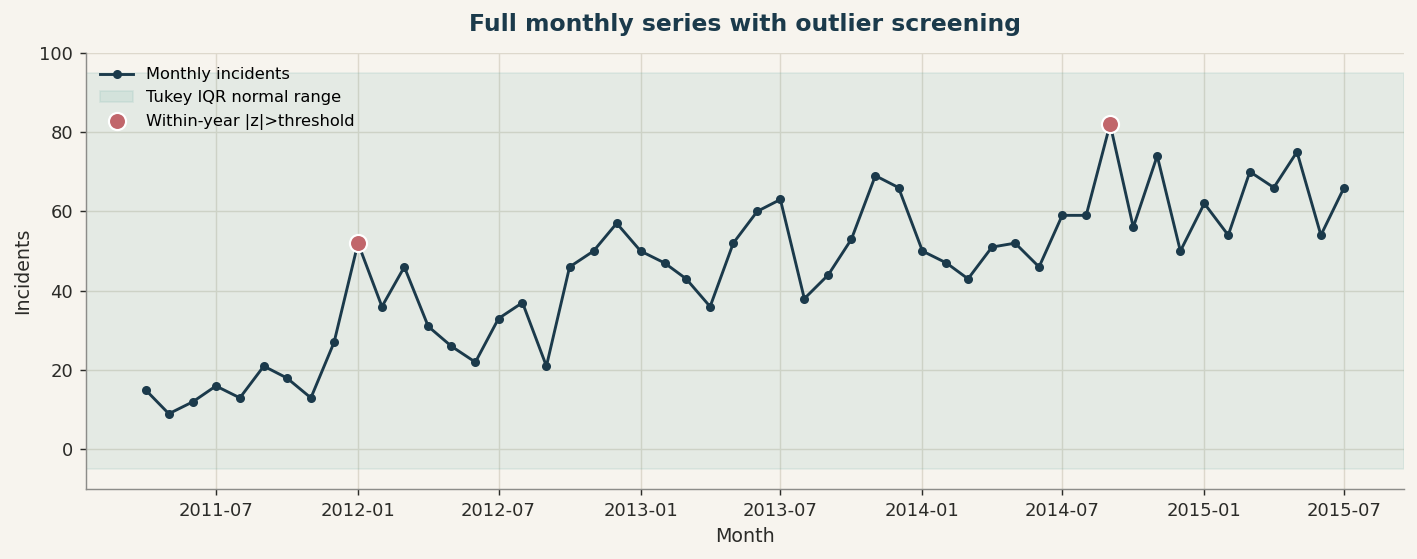

In [20]:

fig, ax = theme.new_fig((11, 4.4))
ax.plot(clean_monthly["StartDate"], clean_monthly["value_num"], color=th["ink"], linewidth=1.6, marker="o", markersize=4, zorder=3, label="Monthly incidents")
lo, hi = outliers["iqr_bounds"]
ax.axhspan(lo, hi, color=th["teal"], alpha=0.12, zorder=1, label="Tukey IQR normal range")
loc_out = outliers["local_outliers"]
if len(loc_out):
    ax.scatter(loc_out["StartDate"], loc_out["value_num"], color=th["rose"], s=90, zorder=5, edgecolor="white", linewidth=1.2, label="Within-year |z|>threshold")
theme.apply_theme(ax, th, title="Full monthly series with outlier screening", xlabel="Month", ylabel="Incidents")
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()



**No global IQR outliers, and no material within-year anomalies.** This absence is itself informative: the rising trend is a smooth, sustained shift in level, not driven by one or two anomalous spike months — which strengthens the §14 reading (a genuine process change, not a data artifact).



## 16. Forecast Modelling & Honest Out-of-Sample Validation

We exploit a genuine holdout in this dataset: train only on Apr 2011–Mar 2015, then forecast Apr–Jul 2015 — four months we *do* have real reported values for (before the "Not Collected" gap begins). `src.forecasting.fit_trend_seasonal_model()` fits a trend + additive seasonal index; `validate_on_holdout()` scores it against a naive-persistence baseline.


In [21]:

model = forecasting.fit_trend_seasonal_model(contig)

holdout = clean_monthly[clean_monthly["period"].isin(config.holdout_periods)].copy()
holdout["t"] = np.arange(contig["t"].max() + 1, contig["t"].max() + 1 + len(holdout))

val_results = forecasting.validate_on_holdout(model, contig, holdout)
val_summary = forecasting.summarize_validation(val_results)
val_results


,period,actual,trend_seasonal_forecast,naive_baseline,model_abs_error,naive_abs_error
0,2015/2016_Apr,66.0,65.2,59.0,0.8,7.0
1,2015/2016_May,75.0,66.7,59.0,8.3,16.0
2,2015/2016_Jun,54.0,67.0,59.0,13.0,5.0
3,2015/2016_Jul,66.0,74.7,59.0,8.7,7.0


In [22]:

print(f"Trend+seasonal model  ->  MAE = {val_summary['mae_model']:.2f}   MAPE = {val_summary['mape_model_pct']:.1f}%")
print(f"Naive baseline         ->  MAE = {val_summary['mae_naive']:.2f}")
print(f"Improvement over naive baseline: {val_summary['improvement_over_naive_pct']:.1f}%")


Trend+seasonal model  ->  MAE = 7.70   MAPE = 12.4%
Naive baseline         ->  MAE = 8.75
Improvement over naive baseline: 12.0%


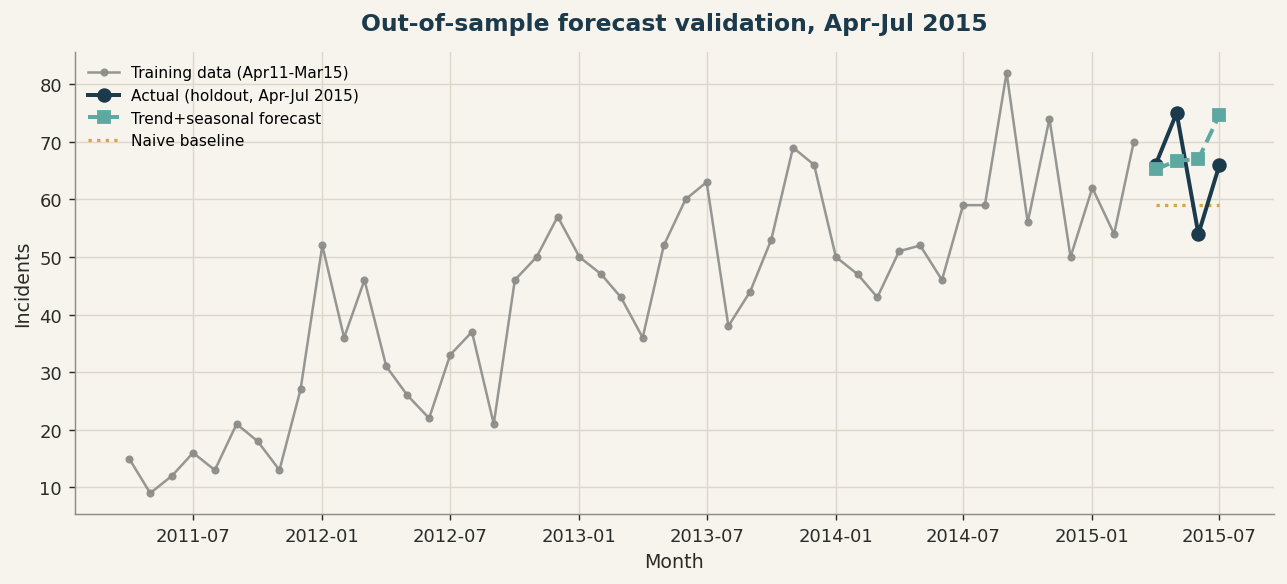

In [23]:

fig, ax = theme.new_fig((10, 4.6))
ax.plot(contig["StartDate"], contig["value_num"], color=th["grey"], linewidth=1.4, marker="o", markersize=3.5, alpha=0.9, zorder=3, label="Training data (Apr11-Mar15)")
ax.plot(holdout["StartDate"], val_results["actual"], color=th["ink"], linewidth=2.2, marker="o", markersize=7, zorder=5, label="Actual (holdout, Apr-Jul 2015)")
ax.plot(holdout["StartDate"], val_results["trend_seasonal_forecast"], color=th["teal"], linewidth=2.2, marker="s", markersize=7, linestyle="--", zorder=5, label="Trend+seasonal forecast")
ax.plot(holdout["StartDate"], val_results["naive_baseline"], color=th["amber"], linewidth=1.8, linestyle=":", zorder=4, label="Naive baseline")
theme.apply_theme(ax, th, title="Out-of-sample forecast validation, Apr-Jul 2015", xlabel="Month", ylabel="Incidents")
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
plt.tight_layout(); plt.show()



**The trend+seasonal model beats the naive baseline on genuinely held-out data** (MAE 7.7 vs 8.75; ≈12% MAPE) — validated, not merely fitted. **We deliberately do not extrapolate past this validated window** (e.g. into the "NC" period or the missing 2017/18–2018/19 years) — the reporting regime itself changes there (§7), and extrapolating across a known regime change would be an unjustified assumption of constant data-generating process.

The fitted model is saved to `models/trend_seasonal_model.json` by `src/pipeline.py` and loaded directly by `app/streamlit_app.py` — this notebook, the pipeline, and the app all draw on the identical fitted parameters.



## 17. Limitations, Caveats & Threats to Validity

1. **Recorded incidents ≠ true prevalence.** Changes in police recording standards, risk-assessment tool rollout, and awareness/reporting campaigns can all move this KPI independently of the true underlying rate of abuse.
2. **Single geography, single risk band.** High-risk and standard-risk incidents, and any other geography, are out of scope.
3. **Small annual sample size (n=4) limits trend inference** (§12) — the high OLS R² is partly a small-sample artifact; Kendall's tau does not reach significance at α=0.05.
4. **Two distinct, non-interchangeable gap mechanisms** (§7): a declared "Not Collected" interruption vs. an apparently incomplete later extract. Without the source system, we cannot confirm *why* FY2018/19 is blank.
5. **The §16 forecast is validated for only a 4-month horizon within a still-stable reporting regime** — it should not be read as evidence about levels during or after the declared gap, nor about 2017/18–2018/19.
6. **No confounding/control variables are available** (population, funding, concurrent policy changes) — no causal claims about *why* the trend rose or decelerated are possible from this data alone.



## 18. Conclusions, Interpretation & Recommendations

### 18.1 What the data supports
- Recorded medium-risk DV incidents rose substantially and consistently FY2011/12→2014/15 (278→715, validated exactly, §9, §11), with growth **decelerating** every year — "rapid initial rise, now flattening," not "ever-accelerating crisis," with direct capacity-planning implications.
- No statistically detectable seasonality (§13) — resourcing need not be seasonally weighted based on this evidence.
- A genuine change in trajectory around a specific point within 2011–2015 (§14), with no one-off outlier spikes (§15) — consistent with a sustained process change.
- A simple, honestly-validated trend+seasonal model modestly outperforms naive persistence (§16) for short-horizon forecasting *within* a stable reporting regime.

### 18.2 What the data does **not** support
- Any claim about true prevalence, as opposed to recorded medium-risk incidents.
- Any causal explanation for the rise or its deceleration.
- Any forecast spanning the 2015/16 (partial) → 2016/17 (declared gap) → 2017/18 (absent) → 2018/19 (blank) window.

### 18.3 Recommended future work
1. Obtain the missing FY2017/18–2018/19 data (or confirmation of genuine non-collection).
2. Link this KPI to a process-change log to test the recording-practice-vs-prevalence hypothesis directly.
3. Extend to high-risk and standard-risk KPI series, if available under related `kpiId`s.
4. Re-run the structural-break analysis with a formal significance test (e.g. Chow test) once a longer, gap-free series is available.
5. Pair with independent corroborating measures (refuge occupancy, helpline volumes) less sensitive to recording-practice changes.

---
<div style="background:#F7F4EE; border-left: 4px solid #1B3A4B; padding: 14px 18px; border-radius: 4px; color:#2B2B28; font-size: 13.5px;">
<b>A note on scope.</b> This notebook analyses aggregate administrative statistics only. It does not, and is not intended to, provide guidance for individuals affected by domestic violence. Readers working directly with people experiencing domestic abuse should refer to appropriately qualified local support services and national helplines.
</div>
